[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MarcoBattiato/PH6721-Deep-Learning-with-Python/blob/main/Classes/Class_4/04A-DecisionTrees.ipynb)

# 04A — Decision Trees
(by Marco Battiato. For questions/errors/bugs/typos report, please email at marco.battiato.teaching@gmail.com)

**PH6721 — Deep Learning with Python**

**Class 4, Notebook A — Hour 1**

**Instructor:** Marco Battiato (formerly Nanyang Assistant Professor @ Nanyang Technological University)

**email:**  marco.battiato.teaching@gmail.com

**In Person Classes:**  Wednesday 6:30pm - 9:45pm

**Consultation:** remote consultations are to be arranged by writing to marco.battiato.teaching@gmail.com

Classes 2 and 3 built one model and then learned to control it. Every model so far has been a
**weighted sum of features** — a straight line in the inputs, or in features we constructed from
them. `02A` §10 named the one case that construction cannot rescue, and left it for here.

This notebook changes the model itself. A decision tree makes no weighted sum at all: it asks a
sequence of yes-or-no questions about the features and reads the answer off the end of the chain.
That single change repays three debts left open since Class 2, and introduces the failure mode that
Class 4's remaining two hours exist to fix.

## Learning Objectives

By the end of this notebook, students should be able to:

- explain why a threshold relationship defeats a basis expansion but not a tree;
- name the parts of a tree — root, branch, internal node, leaf, depth — and read one;
- say what changes, and what does not, when a tree predicts a number rather than a class, and why a
  classifier is a regressor with a decision threshold on top;
- define **Gini impurity** and compute the **information gain** of a candidate split;
- explain what "greedy, recursive partitioning" means, and why it makes the boundary axis-aligned;
- use depth and **cost-complexity pruning** (`ccp_alpha`) to control a tree's flexibility, and
  recognise them as `03C`'s bias–variance dial in another form;
- state what a tree needs no help with (feature scaling) and what it does badly
  (extrapolation, diagonal boundaries, stability).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, to_rgb
from matplotlib.patches import FancyBboxPatch

from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree, export_text
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

plt.rcParams.update({
    "figure.dpi": 110, "figure.autolayout": True, "font.size": 11,
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.titlepad": 12,
    "axes.labelsize": 12, "axes.grid": True, "grid.alpha": 0.3,
    "axes.spines.top": False, "axes.spines.right": False, "legend.fontsize": 10,
})

rng = np.random.default_rng(0)
species_colours = ["tab:blue", "tab:orange", "tab:green"]      # setosa, versicolor, virginica

# 1. The case a basis expansion cannot rescue

`02A` §10 listed when linear regression is the wrong tool, and one entry on that list was left
undischarged:

> **the relationship is discontinuous** — a threshold, a phase transition, a regime that switches.
> A smooth basis reproduces a smooth function well and a jump badly.

That case is common in physics. A material conducts differently above and below a critical
temperature; a detector saturates; a reaction starts. Below is the simplest version: a measured
signal that sits at one level below 300 K and another above it, with ordinary measurement noise of
0.4 on top.

Three models are fitted to it — a straight line, a degree-9 polynomial (the largest basis expansion
`02C` used), and a decision tree. Only the third has any idea what to do.

       a straight line:   training RMSE 1.522
 a degree-9 polynomial:   training RMSE 0.718
       a decision tree:   training RMSE 0.380


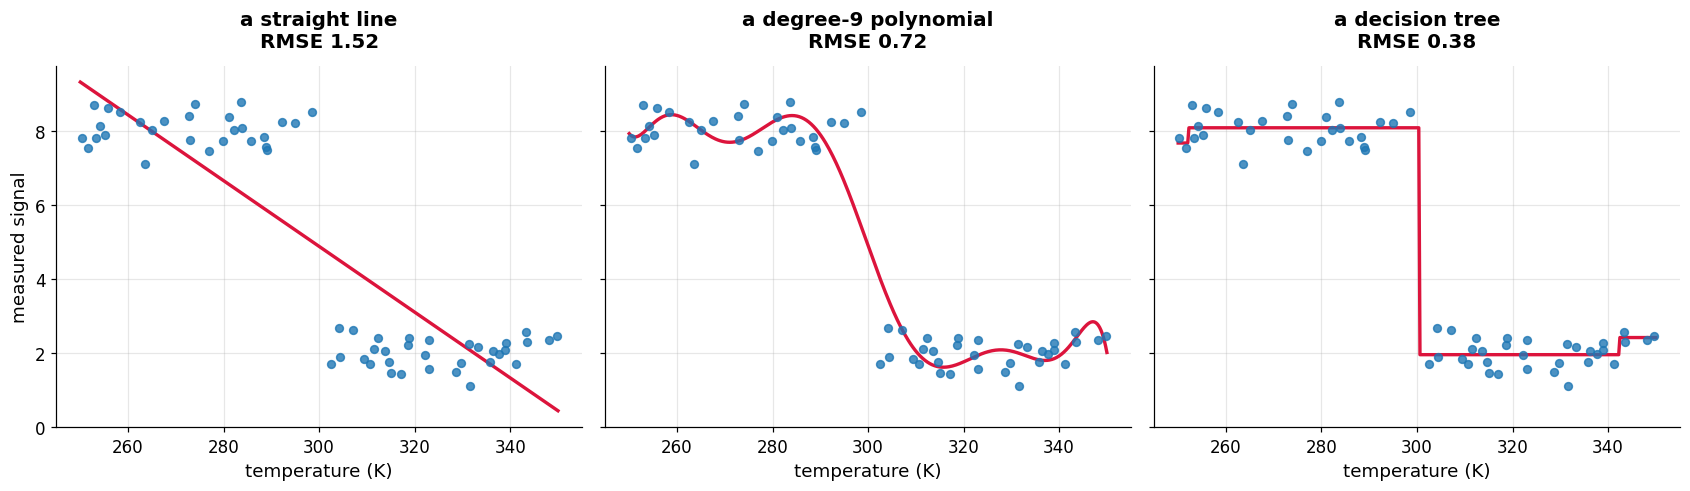


the measurement noise put into the data: 0.400
thresholds the tree chose:  [252.2 300.6 342.3]
the true critical temperature: 300.0


In [2]:
critical_temperature = 300.0
temperature = np.sort(rng.uniform(250, 350, 60))
signal = np.where(temperature < critical_temperature, 8.0, 2.0) + rng.normal(0, 0.4, 60)

X_temperature = temperature.reshape(-1, 1)
grid = np.linspace(250, 350, 400).reshape(-1, 1)

candidates = [
    ("a straight line", LinearRegression()),
    ("a degree-9 polynomial", make_pipeline(PolynomialFeatures(9), StandardScaler(), LinearRegression())),
    ("a decision tree", DecisionTreeRegressor(max_depth=2, random_state=0)),
]

fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.6), sharey=True)
for axis, (name, model) in zip(axes, candidates):
    model.fit(X_temperature, signal)
    rmse = np.sqrt(np.mean((signal - model.predict(X_temperature)) ** 2))
    print(f"{name:>22}:   training RMSE {rmse:.3f}")

    axis.scatter(temperature, signal, s=26, alpha=0.8, zorder=3)
    axis.plot(grid, model.predict(grid), color="crimson", linewidth=2.2)
    axis.set_title(f"{name}\nRMSE {rmse:.2f}")
    axis.set_xlabel("temperature (K)")

axes[0].set_ylabel("measured signal")
plt.show()

# model.tree_ exposes the fitted structure: one entry per node. Nodes that ask a
# question have feature >= 0 and a threshold; leaves are marked with feature = -2.
tree = candidates[2][1]
internal = tree.tree_.feature >= 0
print(f"\nthe measurement noise put into the data: 0.400")
print(f"thresholds the tree chose:  {np.sort(np.round(tree.tree_.threshold[internal], 1))}")
print(f"the true critical temperature: {critical_temperature:.1f}")

The straight line splits the difference and is wrong everywhere. The polynomial does better in
the middle and then does what polynomials do at a step: it oscillates around it, and runs away at
the edges where no data constrain it. Nine extra features bought a worse answer than the tree gets
from three thresholds — one of which, 300.6 K, is doing all the work and sits 0.6 K from the true
critical temperature. Nobody told the tree that there was a threshold, or where to look for it.

The tree matches the noise floor almost exactly, because a step is what a tree *is*. It has no
smoothness to violate. Where the linear model must express "signal changes with temperature" as a
rate, the tree expresses it as a question — *is the temperature below 300?* — and the discontinuity
that defeated the basis expansion is the tree's native vocabulary.

> This does not make trees better than linear models. It makes them differently shaped, and
> section 7 shows the same property costing them dearly on a smooth curve.

One point of vocabulary before going on. The target here was a continuous measurement, so the model
fitted was a `DecisionTreeRegressor`. From section 2 onward the target is a species and the
estimator is a `DecisionTreeClassifier`. That switch is deliberate; section 2 says what it changes,
and section 7 shows how little that is.

# 2. What a tree is

A decision tree is a sequence of yes-or-no questions, each about a single feature, arranged so that
the answer to one determines which question is asked next. Every question has the same form:

$$
\text{is } x_j \le t \; ?
$$

one feature $x_j$, one threshold $t$. Answer enough of them and you arrive somewhere that gives you
a prediction instead of another question.

Trees are drawn, and the drawing has a vocabulary that the rest of this notebook uses constantly.
The figure below names the parts on a tree with nothing in it.

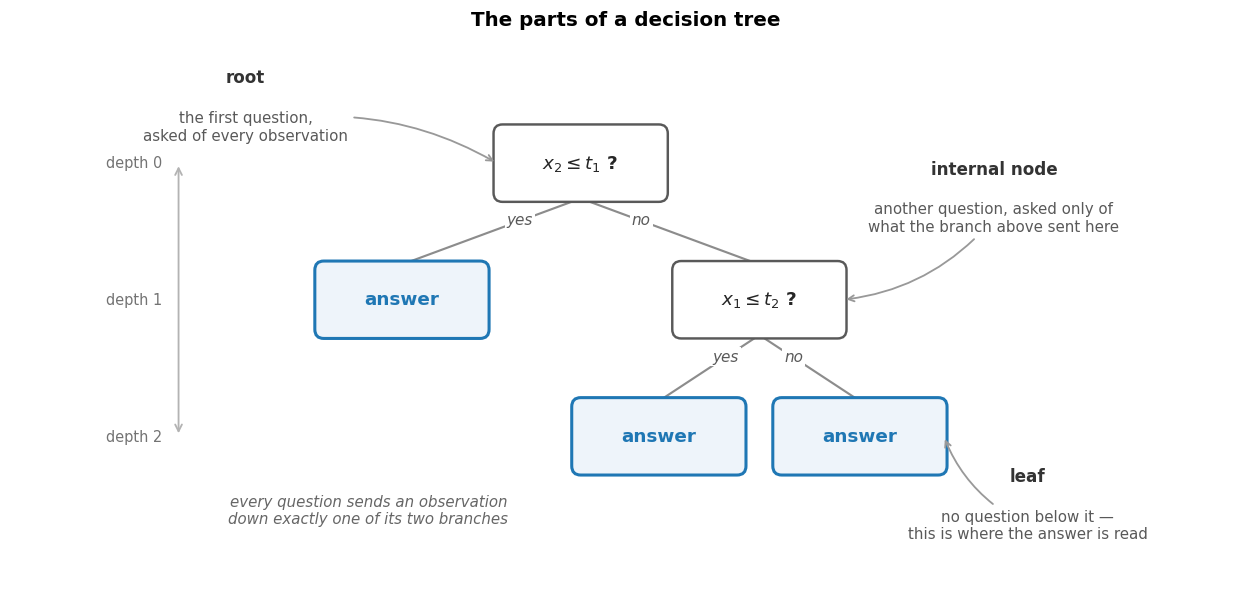

In [3]:
fig, axis = plt.subplots(figsize=(11.5, 5.6))
box_w, box_h = 1.5, 0.62

sketch = {"root":  (0.0,  2.0, "$x_2 \\leq t_1$ ?", "question"),
          "leafA": (-1.6, 0.8, "answer", "leaf"),
          "inner": (1.6,  0.8, "$x_1 \\leq t_2$ ?", "question"),
          "leafB": (0.7, -0.4, "answer", "leaf"),
          "leafC": (2.5, -0.4, "answer", "leaf")}

for parent, child, answer in [("root", "leafA", "yes"), ("root", "inner", "no"),
                              ("inner", "leafB", "yes"), ("inner", "leafC", "no")]:
    x0, y0 = sketch[parent][:2]
    x1, y1 = sketch[child][:2]
    axis.plot([x0, x1], [y0 - box_h / 2, y1 + box_h / 2], color="0.55", linewidth=1.4, zorder=1)
    axis.text(x0 + (x1 - x0) * 0.34, y0 - box_h / 2 - 0.19, answer, ha="center", va="center",
              fontsize=10, style="italic", color="0.35",
              bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.4}, zorder=4)

for x, y, text, kind in sketch.values():
    leaf = kind == "leaf"
    axis.add_patch(FancyBboxPatch((x - box_w / 2, y - box_h / 2), box_w, box_h,
                                  boxstyle="round,pad=0.03,rounding_size=0.08",
                                  facecolor="#eef4fa" if leaf else "white",
                                  edgecolor="tab:blue" if leaf else "0.35",
                                  linewidth=2.0 if leaf else 1.6, zorder=2))
    axis.text(x, y, text, ha="center", va="center", fontsize=12, zorder=4,
              fontweight="bold", color="tab:blue" if leaf else "0.15")

for target, (tx, ty), term, detail in [
        ("root",  (-3.0, 2.45), "root", "the first question,\nasked of every observation"),
        ("inner", (3.7, 1.65), "internal node",
         "another question, asked only of\nwhat the branch above sent here"),
        ("leafC", (4.0, -1.05), "leaf",
         "no question below it —\nthis is where the answer is read")]:
    x, y = sketch[target][:2]
    axis.text(tx, ty + 0.30, term, ha="center", va="center", fontsize=11,
              fontweight="bold", color="0.2", zorder=5)
    axis.annotate(detail, xy=(x + (box_w / 2 if tx > x else -box_w / 2), y), xytext=(tx, ty - 0.13),
                  ha="center", va="center", fontsize=9.8, color="0.35", zorder=5,
                  arrowprops={"arrowstyle": "->", "color": "0.6", "linewidth": 1.2,
                              "connectionstyle": "arc3,rad=-0.2"})

axis.annotate("", xy=(-3.6, 2.0), xytext=(-3.6, -0.4),
              arrowprops={"arrowstyle": "<->", "color": "0.7", "linewidth": 1.2})
for y, label in [(2.0, "depth 0"), (0.8, "depth 1"), (-0.4, "depth 2")]:
    axis.text(-3.75, y, label, ha="right", va="center", fontsize=9.5, color="0.45")
axis.text(-1.9, -1.05, "every question sends an observation\ndown exactly one of its two branches",
          ha="center", va="center", fontsize=9.8, style="italic", color="0.4")

axis.set_xlim(-5.1, 5.9)
axis.set_ylim(-1.75, 3.05)
axis.axis("off")
axis.set_title("The parts of a decision tree")
plt.show()

- The **root** is the first question. Every observation starts there.
- A **branch** is one of the two answers leading down from a question — *yes* on one side, *no* on
  the other. An observation takes exactly one of them.
- An **internal node** is a further question, asked only of the observations that the branches above
  it sent that way.
- A **leaf** is a node with no question beneath it. It has none because it has the answer: to
  predict, follow the branches down from the root until you land in a leaf, and report what that
  leaf says.
- The **depth** of a node is how many questions were needed to reach it, and the depth of the tree
  is the depth of its deepest leaf. The one drawn above has depth 2.

Two things follow immediately. Every observation ends in exactly one leaf, so the leaves divide the
data into groups that neither overlap nor leave anything out. And nowhere along the way is there any
arithmetic: no coefficient multiplies anything, and a feature is only ever compared with a threshold.

Trees do **both regression and classification**. The questions are found and asked in exactly the
same way for either; only what a leaf reports differs. Section 1's tree was a regressor, because the
target was a temperature. From here the target is a species, so the tree is a classifier — the
easier of the two to draw — and section 7 returns to regression and to how little separates them.

We will use the iris flowers of `02B`, now with all three species and two features, so that the
pictures are readable. `export_text` prints a fitted tree as indented text; the cell after it draws
the same tree as a diagram.

In [4]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
iris = pd.read_csv(url)

features = ["petal_length", "petal_width"]
X_iris = iris[features]
y_iris = iris["species"]
species = sorted(y_iris.unique())

shallow = DecisionTreeClassifier(max_depth=2, random_state=0).fit(X_iris, y_iris)

print(export_text(shallow, feature_names=features))
print(f"training accuracy: {accuracy_score(y_iris, shallow.predict(X_iris)):.3f}"
      f"   with {shallow.get_n_leaves()} leaves")

|--- petal_width <= 0.80
|   |--- class: setosa
|--- petal_width >  0.80
|   |--- petal_width <= 1.75
|   |   |--- class: versicolor
|   |--- petal_width >  1.75
|   |   |--- class: virginica

training accuracy: 0.960   with 3 leaves


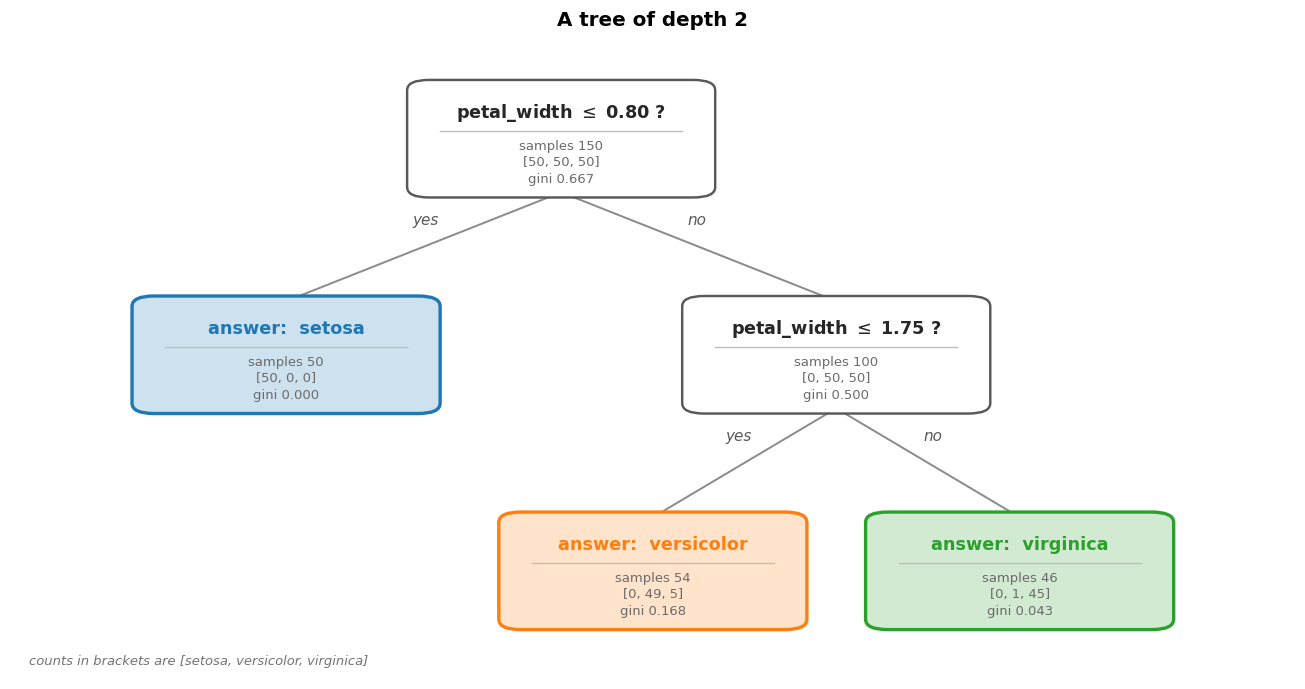

In [5]:
def draw_tree(model, feature_names, class_names, colours, figsize=(12, 6.4), title=None,
              pending=()):
    """Draw a fitted tree: the question in each node, its diagnostics beneath a rule,
    and a predicted class only where the tree actually answers one. Nodes listed in
    `pending` are drawn as still to be worked on."""
    tree = model.tree_
    left, right = tree.children_left, tree.children_right

    position, leaf_counter = {}, [0]                  # leaves left to right, parents centred
    def layout(node, depth):
        if left[node] == -1:
            position[node] = (leaf_counter[0], depth)
            leaf_counter[0] += 1
        else:
            a, b = layout(left[node], depth + 1), layout(right[node], depth + 1)
            position[node] = ((a[0] + b[0]) / 2, depth)
        return position[node]
    layout(0, 0)

    n_leaves = leaf_counter[0]
    n_levels = max(depth for _, depth in position.values()) + 1
    box_w, box_h, row = 0.78, 0.62, 1.25
    centre = lambda node: (position[node][0], -position[node][1] * row)

    fig, axis = plt.subplots(figsize=figsize)
    for node in position:
        x, y = centre(node)
        counts = tree.value[node][0]
        counts = counts / counts.sum() * tree.n_node_samples[node]
        winner = int(np.argmax(counts))
        unfinished = node in pending
        is_leaf = left[node] == -1 and not unfinished

        if unfinished:
            face, edge, width = "white", "0.55", 1.6
        elif is_leaf:
            face = tuple(0.78 + 0.22 * channel for channel in to_rgb(colours[winner]))
            edge, width = colours[winner], 2.2
        else:
            face, edge, width = "white", "0.35", 1.6
        axis.add_patch(FancyBboxPatch((x - box_w / 2, y - box_h / 2), box_w, box_h,
                                      boxstyle="round,pad=0.03,rounding_size=0.06",
                                      facecolor=face, edgecolor=edge, linewidth=width,
                                      linestyle=":" if unfinished else "-", zorder=2))

        if unfinished:
            headline = "not pure — split again"
        elif is_leaf:
            headline = f"answer:  {class_names[winner]}"
        else:
            headline = f"{feature_names[tree.feature[node]]} $\\leq$ {tree.threshold[node]:.2f} ?"
        axis.text(x, y + 0.155, headline, ha="center", va="center", zorder=4, fontsize=11.5,
                  fontweight="bold",
                  color="0.45" if unfinished else (colours[winner] if is_leaf else "0.15"))
        axis.plot([x - box_w / 2 + 0.06, x + box_w / 2 - 0.06], [y + 0.045] * 2,
                  color="0.75", linewidth=0.9, zorder=4)
        axis.text(x, y - 0.135,
                  f"samples {tree.n_node_samples[node]}\n"
                  f"[{', '.join(str(int(round(c))) for c in counts)}]\n"
                  f"gini {tree.impurity[node]:.3f}",
                  ha="center", va="center", fontsize=8.6, color="0.42", linespacing=1.35, zorder=4)

    for node in position:
        if left[node] == -1:
            continue
        x, y = centre(node)
        for child, answer, side in [(left[node], "yes", -1), (right[node], "no", 1)]:
            child_x, child_y = centre(child)
            axis.plot([x, child_x], [y - box_h / 2, child_y + box_h / 2],
                      color="0.55", linewidth=1.3, zorder=1)
            axis.text(x + (child_x - x) * 0.42 + side * 0.055, y - box_h / 2 - 0.16, answer,
                      ha="center", va="center", fontsize=10, style="italic", color="0.35",
                      bbox={"facecolor": "white", "edgecolor": "none", "pad": 1.4}, zorder=4)

    axis.set_xlim(-0.75, n_leaves - 0.25)
    axis.set_ylim(-(n_levels - 1) * row - 0.62, 0.55)
    axis.text(-0.7, -(n_levels - 1) * row - 0.52,
              "counts in brackets are [" + ", ".join(class_names) + "]",
              fontsize=8.6, style="italic", color="0.45", ha="left", va="center")
    axis.axis("off")
    if title:
        axis.set_title(title)
    plt.show()


draw_tree(shallow, features, species, species_colours, title="A tree of depth 2")

Read one flower through it. A flower with petal width 1.2 cm answers *no* to `petal_width <= 0.8`,
takes the right branch, answers *yes* to `petal_width <= 1.75`, and lands in the leaf that says
**versicolor**. Two comparisons, no arithmetic.

The drawing follows the usual convention for decision trees, and the convention carries meaning.
Above the rule in each box is what that node *does*; below it is the evidence the training data left
behind. An internal node does exactly one thing — it asks a question — so it carries no species at
all. Only a leaf answers, and only leaves are coloured and named.

> `scikit-learn`'s own `plot_tree` draws the same tree in a single line and is what you will meet
> elsewhere. It labels **every** node with a class, internal ones included, where the label means
> "the majority species among the flowers that reach here" rather than a prediction. That is a
> useful quantity when pruning — section 6 needs it — and a reliable source of confusion when
> reading a tree, which is why the drawing above keeps the question and the diagnostics apart.

The three diagnostics under the rule are the same in every box:

- **`samples`** is how many training flowers reach that node, and the bracketed triple is how they
  divide among the three species. The root has all 150, split 50/50/50; the left-hand leaf has 50
  and they are all setosa.
- **`gini`**, below. The third thing worth noticing is not a label at all: the tree used **only
  `petal_width`**, twice, and never asked about petal length. Nothing forced that, and section 3
  shows how close the alternative was.

That leaves **`gini`**, which needs a definition, because the entire training algorithm is built on
it. It measures how *mixed* a node is. For a node in which the classes occur in proportions
$p_1, \dots, p_K$, the **Gini impurity** is

$$
\text{Gini} \;=\; 1 - \sum_{k} p_k^2
$$

It is zero when every observation in the node belongs to a single class, and largest when the
classes are spread evenly. Both extremes are in the drawing. The root holds fifty of each species,
so each $p_k = 1/3$ and its Gini is $1 - 3 \times (1/3)^2 = 0.667$ — as mixed as three classes can
be. The leftmost leaf holds all fifty setosa and nothing else, so $p_{\text{setosa}} = 1$ and its
Gini is $1 - 1^2 = 0$. A node with impurity zero is one the tree has no reason to split further,
which is why that branch stops after a single question.

Notice also what is absent. There are no coefficients, no intercept, and no units anywhere in the
model: the tree stores thresholds in whatever units the data arrived in, and compares against them.
Section 8 draws the practical consequence.

# 3. Choosing a split

Everything above assumed the questions were given. They are not — the tree has to find them, and
the rule for finding them is the whole algorithm.

Start with what makes a node good, which section 2 has already answered. A node is useful when the
flowers in it mostly agree, and useless when they are evenly mixed, because then knowing that an
observation landed there tells you nothing. That quantity is the node's **impurity**, and section 2
gave the measure of it:

$$
\text{Gini} \;=\; 1 - \sum_k p_k^2
$$

Zero when the node is pure — one class, $p_k = 1$ — and largest when the classes are evenly mixed.
It carries one further reading worth having: the Gini impurity is **the probability that two
observations drawn at random from the node belong to different classes**. A pure node never yields
a disagreeing pair; an evenly mixed one yields them as often as possible.

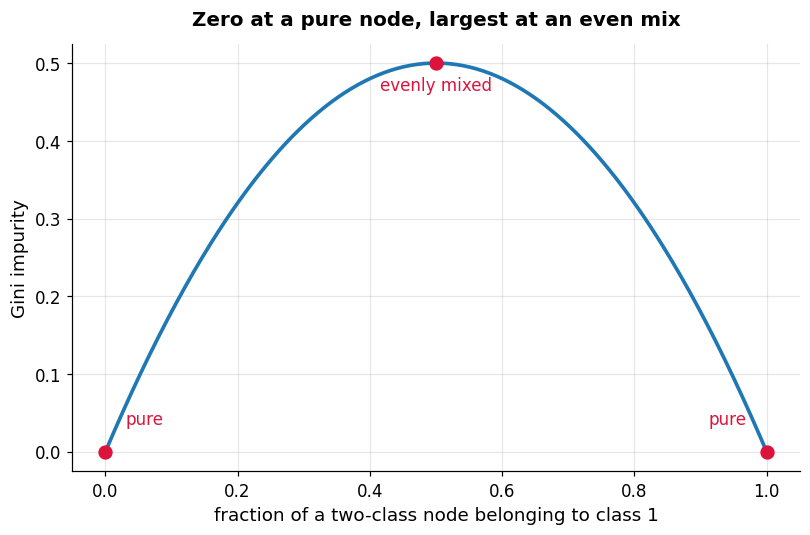

In [6]:
p = np.linspace(0, 1, 300)
gini_curve = 1 - (p ** 2 + (1 - p) ** 2)            # a two-class node

plt.figure(figsize=(7.5, 5))
plt.plot(p, gini_curve, linewidth=2.4)
plt.scatter([0, 0.5, 1], [0, 0.5, 0], s=70, color="crimson", zorder=5)
plt.annotate("pure", xy=(0.03, 0.035), color="crimson", fontsize=11)
plt.annotate("pure", xy=(0.97, 0.035), color="crimson", fontsize=11, ha="right")
plt.annotate("evenly mixed", xy=(0.5, 0.465), color="crimson", fontsize=11, ha="center")
plt.xlabel("fraction of a two-class node belonging to class 1")
plt.ylabel("Gini impurity")
plt.title("Zero at a pure node, largest at an even mix")
plt.show()

## 3.1 Information gain, and the tree built by hand

A split takes one node and produces two. It is worth making when the two children are, on average,
purer than the parent was. The improvement is the **information gain**:

$$
\text{gain} \;=\; I(\text{parent})
\;-\; \frac{n_L}{n} I(\text{left}) \;-\; \frac{n_R}{n} I(\text{right})
$$

where $I$ is the impurity and $n_L, n_R$ are how many observations went each way. The children are
weighted by size, so a split that peels three observations into a pure node earns very little: it
purified almost nothing.

The tree's rule is then simply: **try every feature and every threshold, and take the split with the
largest gain.** There is nothing cleverer than that.

The rest of this section carries that rule out by hand, and rebuilds section 2's tree from nothing.
Start with one feature, `petal_width`, and every threshold it offers.

the node we are splitting: 150 flowers, impurity 0.6667


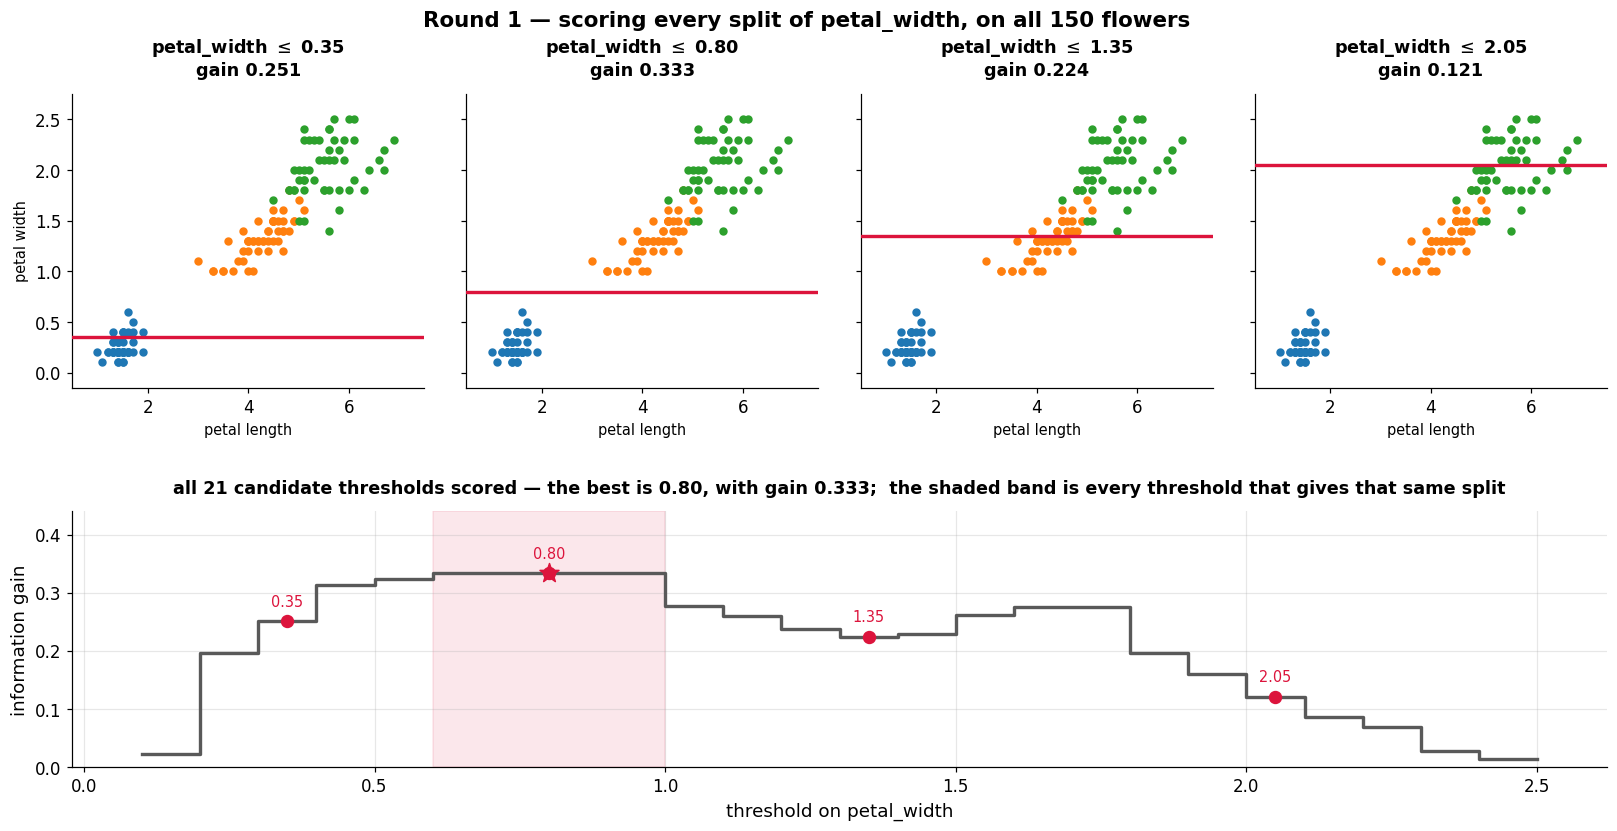

In [7]:
labels = y_iris.to_numpy()

def impurity(mask):
    """Gini impurity of the flowers selected by a boolean mask."""
    counts = np.array([np.sum(labels[mask] == s) for s in species], dtype=float)
    proportions = counts / counts.sum()
    return 1 - (proportions ** 2).sum()

def gain_curve(feature, mask):
    """Information gain of every candidate threshold on one feature, inside one node.

    The gain only changes when the threshold crosses an observed value, so it is constant
    on each interval between neighbouring ones; `observed` marks where those intervals are.
    """
    values = X_iris[feature].to_numpy()
    observed = np.unique(values[mask])
    thresholds = (observed[:-1] + observed[1:]) / 2          # midway between neighbours
    parent = impurity(mask)

    gains = []
    for t in thresholds:
        left, right = mask & (values <= t), mask & (values > t)
        gains.append(parent - (left.sum() * impurity(left)
                               + right.sum() * impurity(right)) / mask.sum())
    return thresholds, np.array(gains), observed


def scan_feature(feature, mask, marks, title):
    """Draw a few candidate splits on the petal plane, and every candidate's gain below."""
    thresholds, gains, observed = gain_curve(feature, mask)
    horizontal = feature == "petal_width"

    fig = plt.figure(figsize=(15, 7.6))
    fig.set_layout_engine("none")            # the gridspec below sets its own spacing
    grid = fig.add_gridspec(2, len(marks), height_ratios=[1.15, 1], hspace=0.45, wspace=0.12,
                            left=0.055, right=0.985, top=0.88, bottom=0.075)
    for column, t in enumerate(marks):
        k = int(np.argmin(abs(thresholds - t)))
        axis = fig.add_subplot(grid[0, column])
        axis.scatter(X_iris.loc[~mask, "petal_length"], X_iris.loc[~mask, "petal_width"],
                     s=16, color="0.85", zorder=2)
        for j, name in enumerate(species):
            inside = mask & (labels == name)
            axis.scatter(X_iris.loc[inside, "petal_length"], X_iris.loc[inside, "petal_width"],
                         s=20, color=species_colours[j], zorder=3)
        (axis.axhline if horizontal else axis.axvline)(thresholds[k], color="crimson",
                                                       linewidth=2.2, zorder=4)
        axis.set_title(f"{feature} $\\leq$ {thresholds[k]:.2f}\ngain {gains[k]:.3f}", fontsize=11.5)
        axis.set_xlim(0.5, 7.5)
        axis.set_ylim(-0.15, 2.75)
        axis.set_xlabel("petal length", fontsize=9.5)
        axis.grid(False)
        if column == 0:
            axis.set_ylabel("petal width", fontsize=9.5)
        else:
            axis.set_yticklabels([])

    wide = fig.add_subplot(grid[1, :])
    # the gain holds still between neighbouring observed values, so draw it as it is
    wide.plot(np.repeat(observed, 2)[1:-1], np.repeat(gains, 2), linewidth=2.2, color="0.35")
    best = int(np.argmax(gains))
    wide.axvspan(observed[best], observed[best + 1], color="crimson", alpha=0.10, zorder=0)
    for t in marks:
        k = int(np.argmin(abs(thresholds - t)))
        wide.scatter([thresholds[k]], [gains[k]], s=60, color="crimson", zorder=5)
        wide.annotate(f"{thresholds[k]:.2f}", xy=(thresholds[k], gains[k]), xytext=(0, 10),
                      textcoords="offset points", ha="center", fontsize=9.5, color="crimson")
    wide.scatter([thresholds[best]], [gains[best]], s=170, marker="*", color="crimson", zorder=6)
    wide.set_ylim(0, gains.max() * 1.32)
    wide.set_xlabel(f"threshold on {feature}")
    wide.set_ylabel("information gain")
    wide.set_title(f"all {len(thresholds)} candidate thresholds scored — the best is "
                   f"{thresholds[best]:.2f}, with gain {gains[best]:.3f};  the shaded band is "
                   f"every threshold that gives that same split", fontsize=11.5, pad=12)
    fig.suptitle(title, fontsize=14, fontweight="bold")
    plt.show()


everything = np.ones(len(labels), dtype=bool)
print(f"the node we are splitting: {everything.sum()} flowers, impurity {impurity(everything):.4f}")
scan_feature("petal_width", everything, [0.35, 0.80, 1.35, 2.05],
             "Round 1 — scoring every split of petal_width, on all 150 flowers")

Read the bottom panel first. Every one of the twenty-one thresholds `petal_width` offers has been
scored, and the four marked points are the four pictures above it. A threshold low in the range cuts
setosa in half and earns 0.251. One at 1.35 cuts through the middle of versicolor and earns 0.224.
One at 2.05 barely separates anything and earns 0.121. The best, at **0.80**, is the cut that puts
all fifty setosa on one side and nothing else with them.

The curve is drawn as a staircase because that is what it is. Sliding the threshold does nothing at
all until it crosses an observed value and moves a flower from one side to the other, so the gain
holds still between neighbouring measurements and jumps when it passes one. There is no smooth curve
underneath to be revealed by looking more closely.

That is why the winning step is a band rather than a point, and the band is shaded. Setosa reaches
0.6 and the next species begins at 1.0, so *every* threshold in that gap makes exactly the same
split and earns exactly the same 0.3333. `scikit-learn` reports 0.80 because it puts the threshold
midway between the two neighbouring observed values. A threshold is not a measured quantity — it is
the middle of an empty interval, and the width of that interval is visible in the figure.

That is one feature. The rule says try them all, so `petal_length` is scanned the same way and the
better of the two is taken.

In [8]:
print(f"{'feature':>14}{'best threshold':>17}{'gain':>9}")
for feature in features:
    thresholds, gains, _ = gain_curve(feature, everything)
    best = int(np.argmax(gains))
    print(f"{feature:>14}{thresholds[best]:>17.2f}{gains[best]:>9.4f}")

print(f"\nwhat scikit-learn chose for the root:   "
      f"{features[shallow.tree_.feature[0]]} <= {shallow.tree_.threshold[0]:.2f}")

boundary = X_iris["petal_width"]
print(f"\nlargest setosa petal_width {boundary[y_iris == 'setosa'].max():.1f};  "
      f"smallest of the other two species {boundary[y_iris != 'setosa'].min():.1f}")

       feature   best threshold     gain
  petal_length             2.45   0.3333
   petal_width             0.80   0.3333

what scikit-learn chose for the root:   petal_width <= 0.80

largest setosa petal_width 0.6;  smallest of the other two species 1.0


The two are **exactly** equal, at 0.3333. That is a genuine tie rather than a rounding coincidence,
and it happens for a reason peculiar to this dataset: setosa is completely separated from the other
two species in *both* petal measurements, so either question isolates it perfectly, and a split that
achieves perfection cannot be improved on. `scikit-learn` broke the tie by taking the first feature
that reached the maximum.

Do not read too much into it. Ties are the extreme case; the ordinary case is the one round 2 will
show, where one feature wins outright. What the tie does illustrate is worth keeping:

**A tie broken arbitrarily is a tie that a slightly different dataset would break the other way.**
Section 8.3 is where that comes due.

Either way, the root question is settled, and the tree has its first node.

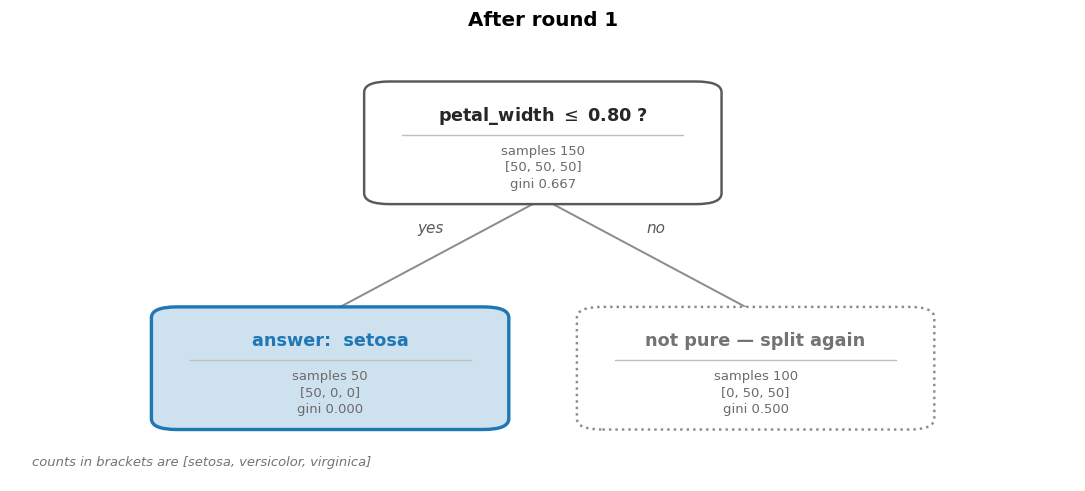

In [9]:
stump = DecisionTreeClassifier(max_depth=1, random_state=0).fit(X_iris, y_iris)

draw_tree(stump, features, species, species_colours, figsize=(10, 4.6),
          pending={2},                       # the right-hand child is not finished
          title="After round 1")

Two children, and they are in different situations.

The left child holds fifty flowers and its impurity is 0. It is **pure**: every flower in it is
setosa, no question could improve it, and there is nothing left to ask. It becomes a **leaf**.

The right child holds the other hundred and its impurity is 0.5 — versicolor and virginica in equal
numbers, which is as mixed as a two-class node can be. So the procedure repeats, with one change
that is the whole of recursion: **the scan is run again, but only on the flowers that reached this
node.** The fifty setosa play no further part; they are greyed out below.

the node we are splitting: 100 flowers, impurity 0.5000


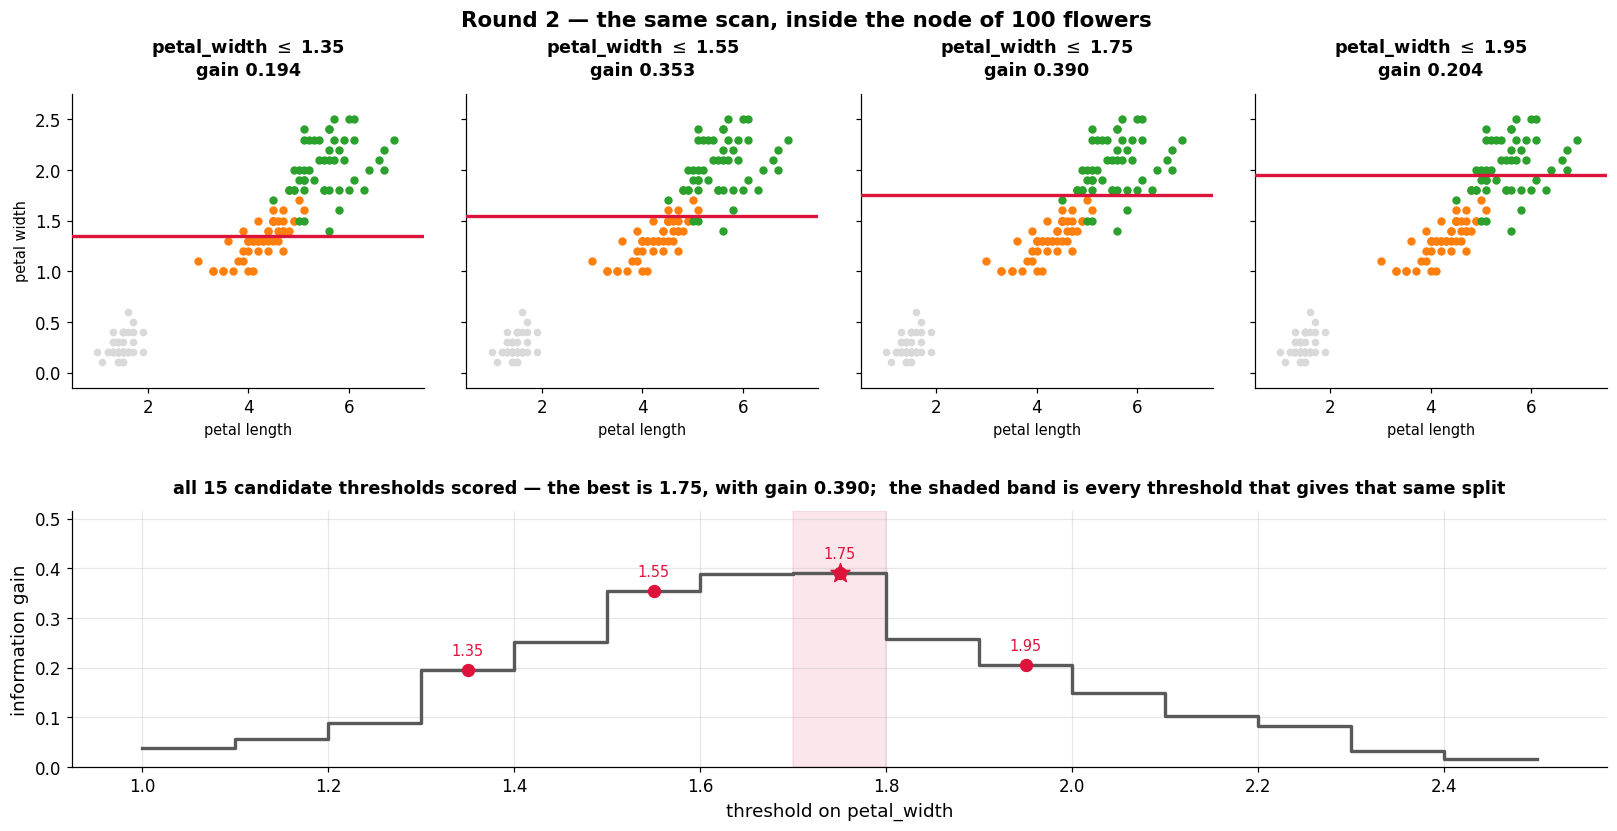


       feature   best threshold     gain
  petal_length             4.75   0.3735
   petal_width             1.75   0.3897


In [10]:
reached_here = X_iris["petal_width"].to_numpy() > 0.80

print(f"the node we are splitting: {reached_here.sum()} flowers, "
      f"impurity {impurity(reached_here):.4f}")
scan_feature("petal_width", reached_here, [1.35, 1.55, 1.75, 1.95],
             "Round 2 — the same scan, inside the node of 100 flowers")

print(f"\n{'feature':>14}{'best threshold':>17}{'gain':>9}")
for feature in features:
    thresholds, gains, _ = gain_curve(feature, reached_here)
    best = int(np.argmax(gains))
    print(f"{feature:>14}{thresholds[best]:>17.2f}{gains[best]:>9.4f}")

Nothing about the procedure changed — the same scan, the same rule — only the set of flowers it
looks at. And this time there is no tie. `petal_width <= 1.75` scores 0.390 and `petal_length <=
4.75` scores 0.374, so the first wins outright. This is the ordinary case; round 1 was the unusual
one.

Note also that no cut in this node reaches a gain anywhere near a clean separation. Versicolor and
virginica overlap, so whichever threshold is chosen, both children will still be mixed.

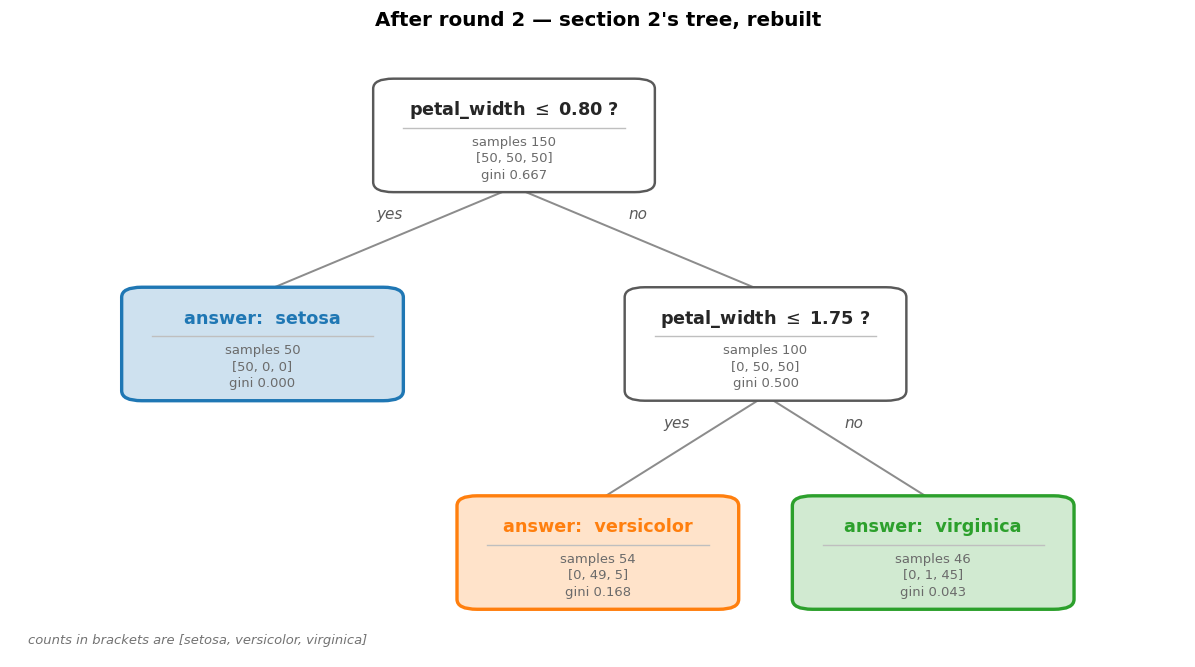

In [11]:
draw_tree(shallow, features, species, species_colours, figsize=(11, 6.2),
          title="After round 2 — section 2's tree, rebuilt")

That is the tree of section 2, derived rather than presented: two rounds of the same three steps —
score every threshold of every feature, take the best, recurse on each child.

## When does it stop?

Recursion needs a base case, and a tree has several. A node becomes a leaf when

- **it is pure.** Impurity zero, as the setosa child was. No split can improve on perfect.
- **it cannot be split.** Every flower in it has identical feature values, so there is no threshold
  that separates any of them. Section 5 meets exactly this: three flowers sharing 4.8 cm by 1.8 cm
  are not all the same species, and no question about petals will ever tell them apart.
- **no split earns anything.** If the best available gain is zero — or below
  `min_impurity_decrease`, if you set one — there is nothing worth doing.
- **you forbade it.** `max_depth` caps how many questions may be asked in a row, and
  `min_samples_leaf` and `min_samples_split` set floors on how small the pieces may get. These are
  choices rather than facts about the data, and section 6 is about making them well.

The tree above stopped for the last reason: `max_depth=2`. Both of its bottom nodes are still
impure — 0.168 and 0.043 — so the algorithm would happily have carried on. Section 4 lets it.

# 4. Recursive partitioning

Score, take the best, recurse: that is **recursive partitioning**, and section 3.1 is the whole
training procedure. Two properties follow from it, and both matter.

**It is greedy.** Each split is chosen to be the best one *now*, with no attempt to check whether a
worse split at the root would allow two much better ones below it. Finding the genuinely optimal
tree is computationally infeasible, and the greedy tree is what everyone uses. It is usually good
and occasionally silly.

**It cuts on one feature at a time.** Every question is $x_j \le t$, which is a cut perpendicular
to one axis. Whatever region a leaf ends up describing is therefore a box with sides parallel to
the axes. A tree cannot draw a diagonal, only a staircase approximating one.

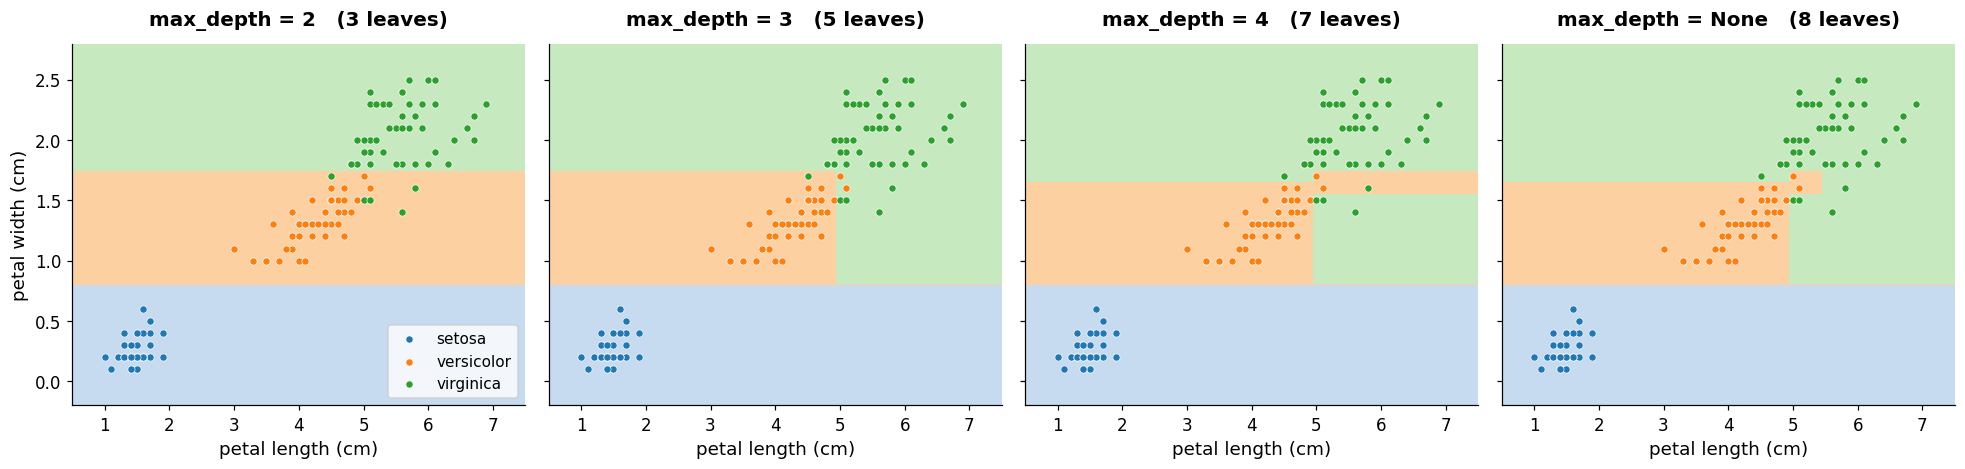

In [12]:
X_values = X_iris.to_numpy()
# contourf needs numbers, not species names: 0, 1, 2 in the order given by `species`
class_codes = pd.Categorical(y_iris, categories=species).codes
region_colours = ListedColormap(["#c6dbef", "#fdd0a2", "#c7e9c0"])

mesh_x, mesh_y = np.meshgrid(np.linspace(0.5, 7.5, 400), np.linspace(-0.2, 2.8, 400))
mesh = pd.DataFrame(np.column_stack([mesh_x.ravel(), mesh_y.ravel()]), columns=features)

def draw_regions(axis, model, title):
    predicted = pd.Categorical(model.predict(mesh), categories=species).codes
    axis.contourf(mesh_x, mesh_y, predicted.reshape(mesh_x.shape),
                  levels=[-0.5, 0.5, 1.5, 2.5], cmap=region_colours)
    for k, name in enumerate(species):
        member = class_codes == k
        axis.scatter(X_values[member, 0], X_values[member, 1], s=22,
                     color=species_colours[k], edgecolor="white", linewidth=0.4, label=name)
    axis.set_title(title)
    axis.set_xlabel("petal length (cm)")
    axis.grid(False)

fig, axes = plt.subplots(1, 4, figsize=(18, 4.4), sharey=True)
for axis, depth in zip(axes, [2, 3, 4, None]):
    tree = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(X_iris, y_iris)
    draw_regions(axis, tree, f"max_depth = {depth}   ({tree.get_n_leaves()} leaves)")

axes[0].set_ylabel("petal width (cm)")
axes[0].legend(loc="lower right")
plt.show()

Left to right, the model is allowed one more question and the picture gains more rectangles. The
first panel is where section 3.1 stopped.
This is the same sequence `02C` drew with polynomial degree and `03B` explained with bias and
variance — the flexibility dial, now with a different knob on it.

The last panel is the one to look at. Grown without a depth limit, the tree pushes a thin orange
tongue rightward into the green region, to capture two versicolor flowers that happen to sit among
the virginica. That tongue is not a fact about irises. It is a fact about two flowers, and the model
has recorded it as though it were a rule.

> This is `03B`'s variance, made unusually literal. Two observations have changed the model's
> prediction over a whole strip of the plane.

# 5. Depth is the flexibility dial

Grown without limit, a tree keeps splitting until every leaf is pure — in the worst case, one leaf
per training observation. Such a tree has training accuracy 1.0 by construction and has learned
nothing generalisable, which is `02C`'s overfitting in its purest available form.

So depth plays the part polynomial degree played in `02C` and `03B`: too little and the model
cannot express the structure, too much and it fits the noise. And the way to choose it is the way
`02C` established — cross-validation, not training accuracy.

The next cell fits trees of increasing depth and reports training accuracy beside
cross-validated accuracy.

1. What will the training accuracy do as depth increases?
2. What will the cross-validated accuracy do?
3. Will the number of leaves keep growing for ever?

**Think about your answer before running this cell.**

In [ ]:
print(f"{'max_depth':>10}{'training':>12}{'cross-validated':>18}{'leaves':>9}")
for depth in [1, 2, 3, 4, 5, 6, 8, None]:
    tree = DecisionTreeClassifier(max_depth=depth, random_state=0).fit(X_iris, y_iris)
    cross_validated = cross_val_score(
        DecisionTreeClassifier(max_depth=depth, random_state=0), X_iris, y_iris, cv=5).mean()
    print(f"{str(depth):>10}{accuracy_score(y_iris, tree.predict(X_iris)):>12.3f}"
          f"{cross_validated:>18.3f}{tree.get_n_leaves():>9}")

Training accuracy climbs and then stops at 0.993, and the leaf count stops at 8. The tree cannot
do better on this data because three flowers share *identical* petal measurements — 4.8 cm by
1.8 cm — and are not all the same species: one versicolor and two virginica. No question about petal
length or width can separate them, so whatever that leaf answers, it is wrong about one flower. Growth stops when every leaf is pure or unsplittable, which is why the
`max_depth = 8` and `max_depth = None` rows are the same tree.

Cross-validated accuracy is the interesting column. It peaks at **depth 3** and then *falls*, and
it is below the training accuracy everywhere — increasingly so as the tree grows. That gap is
exactly what `02C` §2 warned about, and its widening is `03B`'s variance term.

The best tree here is not the most accurate tree on the training data. It is a shallower one that
gets three training flowers wrong.

# 6. Pruning

`max_depth` is a crude instrument, in exactly the way `03C` complained polynomial degree was crude:
it applies one limit to the whole tree. But a tree is not uniformly complicated. One branch may
need four questions to describe a genuinely intricate region while another needs one, and a single
depth limit either starves the first or indulges the second.

There are two families of remedy.

**Pre-pruning** stops growth early, by a rule checked as the tree is built: `max_depth`,
`min_samples_leaf` (refuse to create a leaf with fewer than $m$ observations),
`min_samples_split`, `min_impurity_decrease` (refuse a split whose gain is below a floor). These
are cheap, and they are blind — a split that looks worthless can be the one that makes an excellent
split possible below it, and pre-pruning will never find out.

**Post-pruning** grows the tree fully and then cuts branches back. It cannot be fooled the same way,
because it has already seen what each branch was worth.

## 6.1 Cost-complexity pruning

The standard post-pruning rule will look familiar. For a tree $T$, define

$$
R_\alpha(T) \;=\; R(T) \;+\; \alpha \, |T|
$$

where $R(T)$ is the tree's error on the training data, $|T|$ is its number of leaves, and $\alpha
\ge 0$ sets the price of a leaf. Then prune to whichever subtree minimises $R_\alpha$.

This is `03C`'s bargain with a different currency. There the loss was error plus $\alpha$ times the
size of the coefficients; here it is error plus $\alpha$ times the number of leaves. In both cases
$\alpha = 0$ recovers the unconstrained fit, large $\alpha$ crushes the model to a constant, and
the useful value is in between and is found by cross-validation.

`cost_complexity_pruning_path` returns the only $\alpha$ values that matter: those at which the
pruned tree actually changes. Everything between two of them gives the same tree, so there is no
grid to guess.

In [14]:
full_tree = DecisionTreeClassifier(random_state=0).fit(X_iris, y_iris)
path = full_tree.cost_complexity_pruning_path(X_iris, y_iris)

print(f"{'alpha':>9}{'leaves':>9}{'training':>11}{'cross-validated':>18}")
scored = []
for alpha in path.ccp_alphas:
    pruned = DecisionTreeClassifier(random_state=0, ccp_alpha=alpha).fit(X_iris, y_iris)
    cross_validated = cross_val_score(
        DecisionTreeClassifier(random_state=0, ccp_alpha=alpha), X_iris, y_iris, cv=5).mean()
    scored.append((alpha, pruned.get_n_leaves(), cross_validated))
    print(f"{alpha:>9.4f}{pruned.get_n_leaves():>9}"
          f"{accuracy_score(y_iris, pruned.predict(X_iris)):>11.3f}{cross_validated:>18.3f}")

best_alpha, best_leaves, best_score = max(scored, key=lambda row: row[2])
print(f"\nbest by cross-validation:  alpha = {best_alpha:.4f}"
      f"   {best_leaves} leaves   accuracy {best_score:.3f}")

    alpha   leaves   training   cross-validated
   0.0000        8      0.993             0.947
   0.0042        7      0.993             0.947
   0.0089        5      0.980             0.953


   0.0131        4      0.973             0.960
   0.0297        3      0.960             0.940
   0.2598        2      0.667             0.753
   0.3333        1      0.333             0.400

best by cross-validation:  alpha = 0.0131   4 leaves   accuracy 0.960


Read the last two columns against each other. Training accuracy falls monotonically as $\alpha$
rises — it must, since pruning can only remove distinctions the training data supported.
Cross-validated accuracy does not: it *improves* as the first branches come off, peaks, and then
collapses when pruning goes too far.

The chosen tree has **four leaves and scores 0.960**, against the unpruned tree's eight leaves and
0.947. Half the size and better on data it has not seen. Those four extra leaves were not
describing irises; they were describing the hundred and fifty flowers we happened to measure.

> The last row, $\alpha = 0.3333$, is the tree pruned to a single leaf: no questions, one answer
> for every flower. Its training accuracy is 0.333 — exactly one species in three, which is the
> tree-shaped equivalent of `02B`'s majority-class baseline. The far end of this dial is as bad as
> the far end of `03C`'s, and for the same reason.

<div class="alert alert-success">
<b>Mini-exercise 1 — Pruning by hand</b><br>
Using the printed path above:
<br><br>
1. Fit the tree at the best $\alpha$ and draw it with <code>draw_tree</code> (defined in
section 2). Which questions survived?<br>
2. Which branch of the depth-3 tree in section 4 was removed, and which flowers does the pruned
tree now get wrong?<br>
3. Re-run the whole path on only the first 75 flowers. Does cross-validation choose the same
$\alpha$, and a tree of the same size?<br>
4. `min_samples_leaf` is a pre-pruning rule. Sweep it over 1, 2, 5, 10, 20 with
<code>cross_val_score</code>. Does the best pre-pruned tree match the best post-pruned one?
</div>

In [15]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 7. Regression trees

Section 1 fitted a `DecisionTreeRegressor` to a temperature, and everything since has been a
`DecisionTreeClassifier` fitted to a species. Section 2 said the two are the same method with a
different leaf. Now that the method has been built, that can be made precise.

Exactly three things depend on whether the target is a class or a number:

| | classification | regression |
|---|---|---|
| **what a leaf estimates** | the proportion of each class among the training observations that reach it | the mean target of the training observations that reach it |
| **how a candidate split is scored** | the drop in the Gini impurity of those proportions (section 3) | the drop in the variance of those targets |
| **how the estimate becomes a prediction** | a decision rule is applied: by default the largest proportion wins | nothing further — the estimate *is* the prediction |
| everything else in this notebook | identical | identical |

The first two rows are one idea stated twice. A leaf reports the summary that minimises its own
error — the mean minimises squared error, the majority minimises misclassifications — and a split is
scored by how much of that error it removes. Impurity is not a classification concept that
regression borrows; it is "how spread out is this node", measured in whatever way the target allows.

The third row is the one difference of kind, and section 7.1 is about it. First, the first two rows
are worth checking rather than believing, and the tree from section 1 is already fitted. The cell
below takes each of its leaves and compares what the tree predicts there with the mean of the
training signals that reach it, and the node's stored impurity with their variance.

In [16]:
step_tree = candidates[2][1]            # the DecisionTreeRegressor fitted in section 1
leaf_of = step_tree.apply(X_temperature)   # .apply reports which leaf each observation falls into

print(f"{'leaf':>6}{'samples':>9}{'mean signal in it':>20}{'tree predicts':>15}"
      f"{'variance in it':>17}{'node impurity':>15}")
for leaf in np.unique(leaf_of):
    inside = leaf_of == leaf
    print(f"{leaf:>6}{inside.sum():>9}{signal[inside].mean():>20.3f}"
          f"{step_tree.predict(X_temperature[inside])[0]:>15.3f}"
          f"{signal[inside].var():>17.3f}{step_tree.tree_.impurity[leaf]:>15.3f}")

  leaf  samples   mean signal in it  tree predicts   variance in it  node impurity
     2        2               7.679          7.679            0.022          0.022
     3       26               8.091          8.091            0.183          0.183
     5       28               1.952          1.952            0.137          0.137
     6        4               2.416          2.416            0.012          0.012


Both columns agree in every leaf, exactly. The prediction *is* the mean of the training targets that
reach the leaf, and the impurity the tree stored *is* their variance — the table's first two rows,
confirmed on a fitted model rather than asserted.

With that settled, the interesting question is what such a model looks like. Its predictions are
**piecewise constant**: one value per leaf, changing abruptly at the thresholds. On a step that was
exactly right. On a smooth curve it is exactly wrong.

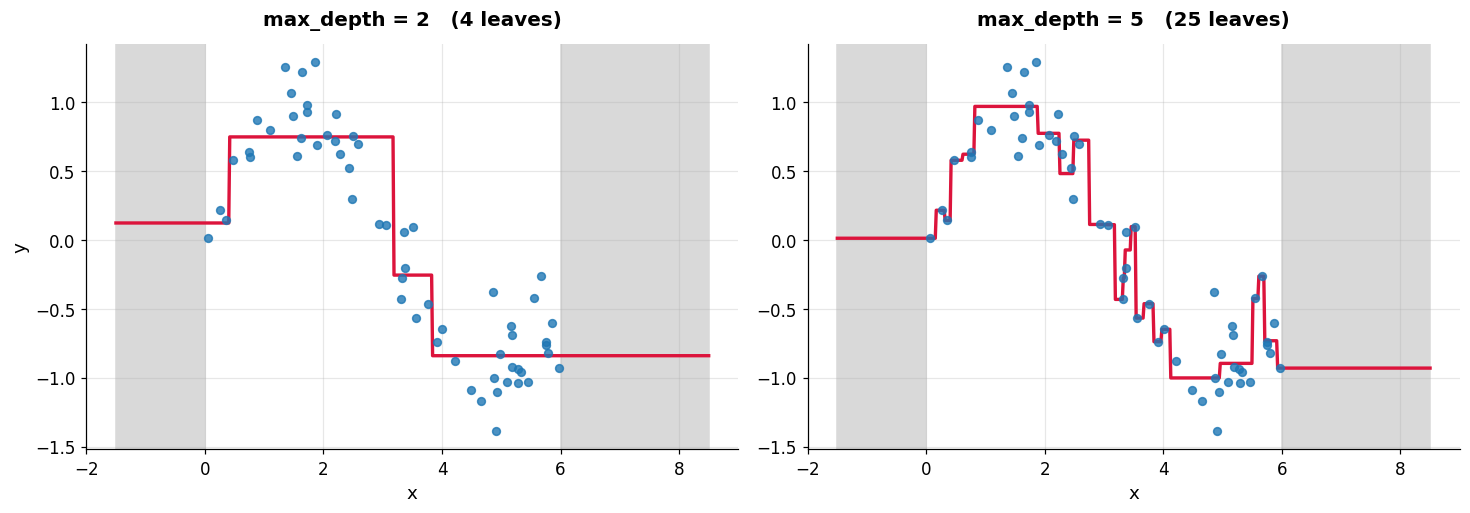

In [17]:
x_smooth = np.sort(rng.uniform(0, 6, 60))
y_smooth = np.sin(x_smooth) + rng.normal(0, 0.2, 60)
extended = np.linspace(-1.5, 8.5, 600).reshape(-1, 1)

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8))
for axis, depth in zip(axes, [2, 5]):
    model = DecisionTreeRegressor(max_depth=depth, random_state=0).fit(
        x_smooth.reshape(-1, 1), y_smooth)
    axis.scatter(x_smooth, y_smooth, s=26, alpha=0.8, zorder=3)
    axis.plot(extended, model.predict(extended), color="crimson", linewidth=2.2)
    axis.axvspan(-1.5, 0, color="0.85")           # shaded: outside the training range
    axis.axvspan(6, 8.5, color="0.85")
    axis.set_title(f"max_depth = {depth}   ({model.get_n_leaves()} leaves)")
    axis.set_xlabel("x")

axes[0].set_ylabel("y")
plt.show()

Two lessons, one in each half of the picture.

**Inside the data**, the tree approximates a smooth curve with a staircase. At depth 2 the
staircase is too coarse; at depth 5 it follows the noise. A polynomial of the right degree would
beat both comfortably here — this is the mirror image of section 1, and the honest statement of
when *not* to reach for a tree.

**Outside the data**, in the shaded strips, the prediction is flat. It must be: the leftmost leaf
says "everything with $x$ below the first threshold gets this value", and that leaf extends to
minus infinity. **A tree cannot extrapolate.** A linear model asked about $x = 8$ gives an answer
that may be wrong but that continues the trend it fitted; a tree gives you the average of the
right-most training points, for ever.

> This is the single most important practical caveat in the notebook. If your test conditions lie
> outside the range you trained on — a higher temperature, a larger molecule, a later year — a tree
> will not tell you it has left familiar ground. It will confidently repeat the nearest thing it
> saw.

## 7.1 A classifier is a regressor with a threshold

The third row of that table is the only difference of kind, and on a two-class problem you can see
how thin it is.

Notice first what a classification leaf actually holds. It does not store a species; it stores the
proportions — `predict_proba` returns them, and `predict` reduces them to a label by taking the
largest. **The word written in section 2's drawing is the result of that reduction, not something
the tree estimated**, and with two classes taking the larger proportion is precisely a threshold
at 0.5.

Now code a target as 0 and 1. The mean of those targets in a leaf *is* the proportion of class 1, so
the table's first row collapses to one number. Its second row collapses too, because for two classes

$$
\text{Gini} \;=\; 1 - p^2 - (1-p)^2 \;=\; 2\,p(1-p)
$$

while $p(1-p)$ is exactly the variance of a 0/1 variable with proportion $p$. Gini is twice the
variance, and a factor of two cannot change which split scores highest.

If all that is right, a classifier and a regressor fitted to the same 0/1 target should not merely
behave similarly. They should be the same tree.

In [18]:
binary_target = (y_iris == "virginica").astype(int)          # 1 for virginica, 0 for the rest

as_classifier = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_iris, binary_target)
as_regressor = DecisionTreeRegressor(max_depth=3, random_state=0).fit(X_iris, binary_target)

print("the same questions, in the same order:",
      np.array_equal(as_classifier.tree_.feature, as_regressor.tree_.feature)
      and np.allclose(as_classifier.tree_.threshold, as_regressor.tree_.threshold))
print("   thresholds:", np.round(as_regressor.tree_.threshold[as_regressor.tree_.feature >= 0], 2))

print("\ngini of every node == 2 x the regressor's variance:",
      np.allclose(as_classifier.tree_.impurity, 2 * as_regressor.tree_.impurity))

probability = as_classifier.predict_proba(X_iris)[:, 1]
print("\nP(virginica) from the classifier == the regressor's prediction:",
      np.allclose(probability, as_regressor.predict(X_iris)))
print("the classifier's label == that number being above 0.5:",
      np.array_equal(as_classifier.predict(X_iris), (probability > 0.5).astype(int)))

print("\nwhat each leaf holds:")
print(f"{'leaf':>6}{'not virginica':>16}{'virginica':>12}{'P(virginica)':>15}{'label':>8}")
for leaf in np.unique(as_classifier.apply(X_iris)):
    inside = as_classifier.apply(X_iris) == leaf
    p = probability[inside][0]
    print(f"{leaf:>6}{(binary_target[inside] == 0).sum():>16}{(binary_target[inside] == 1).sum():>12}"
          f"{p:>15.3f}{int(p > 0.5):>8}")

the same questions, in the same order: True
   thresholds: [1.75 4.95 1.65 1.55 4.85]

gini of every node == 2 x the regressor's variance: True

P(virginica) from the classifier == the regressor's prediction: True
the classifier's label == that number being above 0.5: True

what each leaf holds:
  leaf   not virginica   virginica   P(virginica)   label
     3              97           0          0.000       0
     4               0           1          1.000       1
     6               0           3          1.000       1
     7               2           1          0.333       0
     9               1           2          0.667       1
    10               0          43          1.000       1


Every check passes. Same questions, same thresholds, the same impurity node for node up to the
factor of two, and the classifier's probability is the regressor's prediction to machine precision.
**The classifier is the regressor, plus one comparison with 0.5.**

The leaf table shows what that comparison is doing. Two leaves hold three flowers each and are split
2–1 and 1–2, giving probabilities of 0.333 and 0.667 — and it is only the threshold that turns those
into opposite answers. `03A` §6 swept the threshold from 0.5 down to 0.01 and watched precision and
recall move; the same sweep applies here, and nothing about the fitted tree changes while you do it.
A regression tree has no such step, and so no such choice to get wrong.

> With more than two classes the reduction is `argmax` over the proportions rather than a single
> number, and Gini no longer coincides with one variance. The shape of the argument survives intact:
> the tree estimates a distribution over each region, and a decision rule — which you own — turns
> that distribution into a label.

# 8. What trees need not do, and what they cannot

## 8.1 No scaling, ever

`03C` §2 spent a whole section on a warning: a ridge penalty compares coefficients, coefficients
carry units, and the same data expressed in mol/l and mmol/l gave two entirely different models.
The remedy was to standardise inside the pipeline, and it was not optional.

A tree compares each feature only against thresholds *in that feature*. It never adds two features
together, never compares a coefficient with another coefficient, and so has nothing to be confused
by.

The next cell fits the same tree twice: once on petal length in centimetres, and once with that
one feature multiplied by 1000.

1. Will the two trees make the same predictions?
2. Will the two trees have the same thresholds?

**Think about your answer before running this cell.**

In [ ]:
X_rescaled = X_iris.copy()
X_rescaled["petal_length"] = X_rescaled["petal_length"] * 1000      # cm -> micrometres

in_cm = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_iris, y_iris)
in_um = DecisionTreeClassifier(max_depth=3, random_state=0).fit(X_rescaled, y_iris)

print("identical predictions for every flower:",
      np.array_equal(in_cm.predict(X_iris), in_um.predict(X_rescaled)))

internal = in_cm.tree_.feature >= 0
print(f"\nthresholds, petal length in cm:  {np.round(in_cm.tree_.threshold[internal], 3)}")
print(f"thresholds, petal length in um:  {np.round(in_um.tree_.threshold[internal], 3)}")

The predictions are identical, and the thresholds are the same numbers with the two petal-length
ones multiplied by a thousand — the model was relabelled, not changed. **A tree is invariant under any monotone
rescaling of any individual feature**, so the `StandardScaler` that was mandatory in `03C` is
simply unnecessary here. That is a genuine practical advantage on scientific data, where features
routinely arrive in wildly different units.

It also means a tree cares only about the *order* of a feature's values, not their spacing. A
feature with a long tail needs no log transform to be usable.

## 8.2 Diagonals cost a staircase

`02B` §10 ended on a dataset that defeated logistic regression completely: two classes arranged as
concentric rings, where the model found no straight boundary and answered with the majority class
everywhere. It promised that a decision tree could do this directly. It can — but look at how.

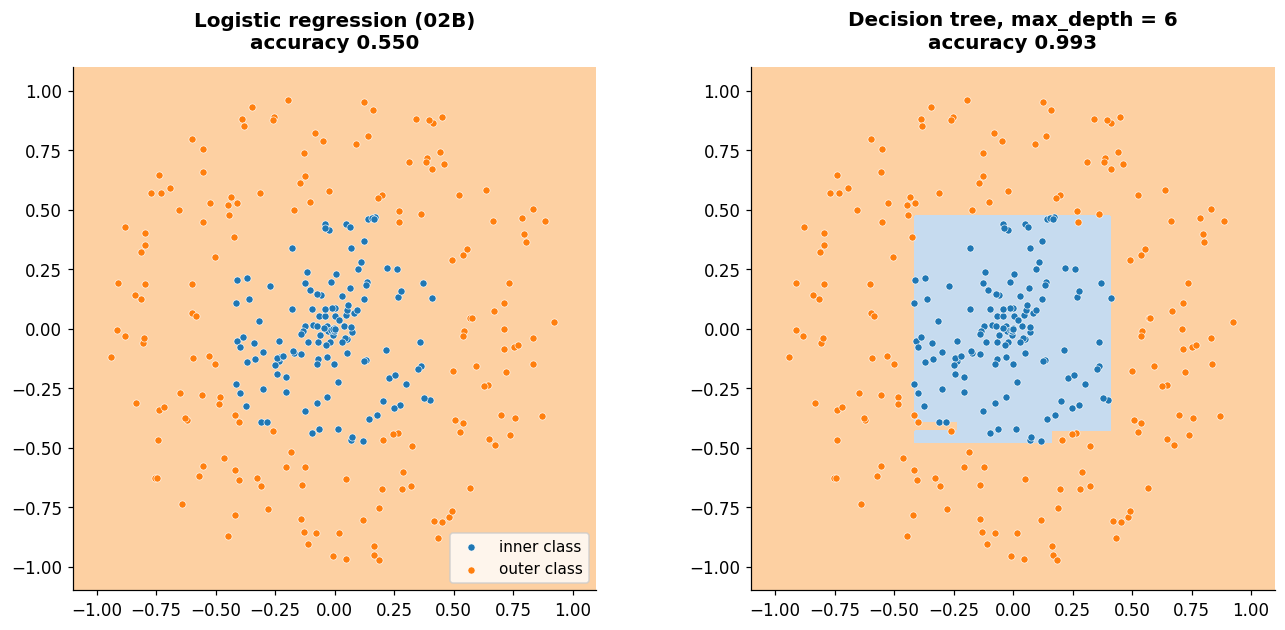

In [20]:
rings_rng = np.random.default_rng(0)                  # the same construction as 02B
radius = rings_rng.uniform(0, 1, 300)
angle = rings_rng.uniform(0, 2 * np.pi, 300)

X_rings = np.column_stack([radius * np.cos(angle), radius * np.sin(angle)])
y_rings = (radius < 0.5).astype(int)                  # inner disc is class 1

ring_x, ring_y = np.meshgrid(np.linspace(-1.1, 1.1, 400), np.linspace(-1.1, 1.1, 400))
ring_mesh = np.column_stack([ring_x.ravel(), ring_y.ravel()])

fig, axes = plt.subplots(1, 2, figsize=(12.5, 5.8))
for axis, model, name in [
        (axes[0], LogisticRegression().fit(X_rings, y_rings), "Logistic regression (02B)"),
        (axes[1], DecisionTreeClassifier(max_depth=6, random_state=0).fit(X_rings, y_rings),
         "Decision tree, max_depth = 6")]:
    axis.contourf(ring_x, ring_y, model.predict(ring_mesh).reshape(ring_x.shape),
                  levels=[-0.5, 0.5, 1.5], cmap=ListedColormap(["#fdd0a2", "#c6dbef"]))
    for value, label, colour in [(1, "inner class", "tab:blue"), (0, "outer class", "tab:orange")]:
        member = y_rings == value
        axis.scatter(X_rings[member, 0], X_rings[member, 1], s=22, color=colour,
                     edgecolor="white", linewidth=0.4, label=label)
    axis.set_title(f"{name}\naccuracy {model.score(X_rings, y_rings):.3f}")
    axis.set_aspect("equal")
    axis.grid(False)

axes[0].legend(loc="lower right")
plt.show()

The tree solves the problem that stopped `02B`, and it does so with no help: no polar coordinates,
no basis expansion, no kernel. That is worth appreciating.

It is also worth seeing the price. The true boundary is a circle, and the tree's is a flight of
steps — because every question it can ask is a cut perpendicular to an axis, and a circle is not
made of those. It spends depth buying resolution on a shape it cannot represent, and it would need
far more depth to smooth the staircase further. A model whose natural boundary *was* curved would
need none of that; Class 5's kernel methods are exactly that model.

## 8.3 The instability that Class 4 exists to fix

Section 3 found the root split decided by an exact tie. Ties are the visible extreme of a general
problem: each split is chosen by a comparison between numbers that are themselves estimated from
the data, and when two candidates are close, a handful of different observations reverses the
decision. And because everything below a node depends on that node, a reversal at the top rewrites
the entire tree beneath it.

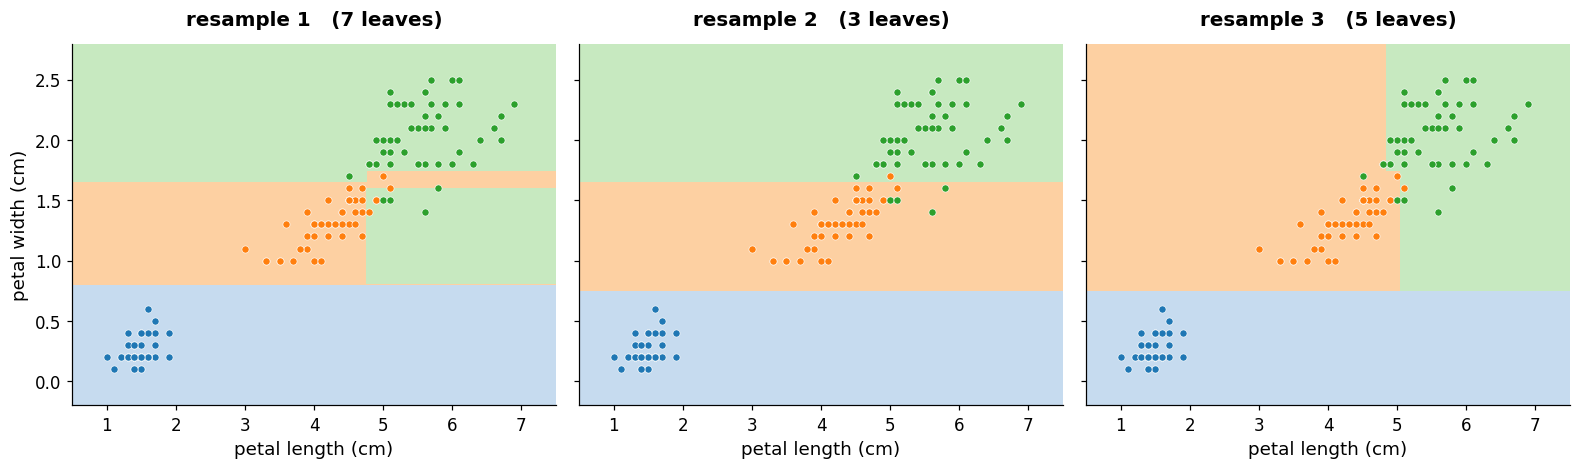

root question, over 30 resamples of the same 150 flowers:
   petal_width <= 0.8     17/30
   petal_width <= 0.75     9/30
   petal_width <= 0.7      3/30
   petal_width <= 1.55     1/30


In [21]:
boot = np.random.default_rng(3)

fig, axes = plt.subplots(1, 3, figsize=(14.5, 4.4), sharey=True)
for axis, k in zip(axes, range(3)):
    rows = boot.integers(0, len(y_iris), len(y_iris))
    resampled = DecisionTreeClassifier(max_depth=4, random_state=0).fit(
        X_iris.iloc[rows], y_iris.iloc[rows])
    draw_regions(axis, resampled, f"resample {k + 1}   ({resampled.get_n_leaves()} leaves)")

axes[0].set_ylabel("petal width (cm)")
plt.show()

roots = {}
for _ in range(30):
    rows = boot.integers(0, len(y_iris), len(y_iris))
    resampled = DecisionTreeClassifier(max_depth=4, random_state=0).fit(
        X_iris.iloc[rows], y_iris.iloc[rows])
    question = (features[resampled.tree_.feature[0]], round(float(resampled.tree_.threshold[0]), 2))
    roots[question] = roots.get(question, 0) + 1

print("root question, over 30 resamples of the same 150 flowers:")
for (feature, threshold), count in sorted(roots.items(), key=lambda item: -item[1]):
    print(f"   {feature} <= {threshold:<6} {count:>3}/30")

Three resamples of the *same* 150 flowers, and three different partitions of the plane — three,
five and seven leaves. Look at how versicolor is separated from virginica in each. One resample
draws a horizontal cut in petal width, another a vertical cut in petal length, and the third adds a
corrective rectangle on top. Those are three different descriptions of the same two species, and
nothing but resampling produced them.

The printed tally is the milder half of the story: the root always asks about petal width, but the
threshold it settles on moves between 0.7 and 0.8. The instability is not mainly in *which* question
comes first — it is in everything that follows.

This is `03C` §4's lasso instability in another guise — there, which of two correlated features
survived; here, which of two near-equivalent questions gets asked. Both come from a discrete choice
made on evidence too thin to support it, and both mean the same thing in practice: **the structure
of a single fitted tree is not a finding.** A tree that asks about petal width first is not
evidence that petal width matters more, any more than a lasso subset was evidence about biology.

And a tree is not merely unstable in its structure. It is unstable in its *predictions*, which is
the part that costs accuracy. In `03B`'s vocabulary a fully grown tree is a low-bias, high-variance
model — it can represent almost anything, and it changes a great deal when the data change a
little.

`03B` also gave the standard cure for variance, and had you build it by hand in its third exercise:
average many independent estimates. Applied to trees, that is a **random forest**, and it is the
whole of `04B`.

<div class="alert alert-success">
<b>Mini-exercise 2 — Reading and breaking a tree</b><br>
1. Refit the depth-3 iris tree using all four features. Which does it ask about, and does the
cross-validated accuracy improve on the two-feature tree of section 5?<br>
2. Take the concentric rings of section 8.2 and sweep <code>max_depth</code> from 2 to 12, plotting
cross-validated accuracy. Where does the staircase stop paying for itself?<br>
3. Add a feature to the iris data that is pure noise (<code>rng.normal</code>, same length). Fit an
unpruned tree. Does it use the noise feature? At what depth does it start to?<br>
4. Fit a <code>DecisionTreeRegressor</code> to the diabetes data of <code>03C</code> and compare its
cross-validated MSE with the ridge model from <code>03C</code> §5. Which wins, and does pruning
change your answer?
</div>

In [22]:
# ==================================================
# STUDENT WORKSPACE
# ==================================================

# Write your solution here.

# 9. Common pitfalls

**Reading a fitted tree as a causal story.** The tree asked about petal width first because it won a
tie by 0.0000. Section 8.3 shows how easily that reverses. Report the tree's *predictions* with
confidence; report its *structure* as one of several near-equivalent descriptions.

**Trusting a tree outside its training range.** Section 7. The prediction stays flat and gives no
warning, which is more dangerous than a linear model's wrong-but-visible extrapolation.

**Judging depth on training accuracy.** It rises monotonically and stops only when the leaves are
pure. It cannot select anything. Cross-validate, as in section 5.

**Scaling the features first.** Harmless but pointless, and it makes the thresholds unreadable —
`petal_width <= 0.80` becomes `petal_width <= -0.62`. Interpretability is a large part of why one
uses a single tree; do not throw it away for a step that does nothing.

**Assuming a deeper tree is a better tree.** Section 6: half the leaves scored better. Complexity
bought with training data is usually a loan, not a purchase.

**Using a single tree where accuracy is what matters.** It rarely wins. Its virtues are
interpretability and its indifference to units and monotone transformations. When you want
accuracy on tabular data you want an ensemble of trees, which is the rest of Class 4.

# Key Takeaways

- A decision tree predicts by asking a sequence of single-feature threshold questions and reading
  the answer off a leaf. There are no coefficients and no weighted sums.
- **One algorithm covers both tasks.** A tree partitions the feature space and estimates the
  target's local distribution in each region. On a two-class target the classifier and the regressor
  are *the same fit* — same questions, same thresholds, and Gini is exactly twice the variance — and
  the classifier differs only by comparing the fitted proportion with 0.5. Choosing that threshold
  is the one step classification adds, and `03A` §6 is why it matters.
- It handles **discontinuous** relationships natively — the case `02A` §10 identified as beyond any
  basis expansion — and gives a curved decision boundary without kernels or new features.
- Splits are chosen greedily by **information gain**, the drop in **Gini impurity** weighted by how
  many observations go each way. Every feature and every threshold is tried; the
  best is taken; the procedure recurses.
- Because each question cuts perpendicular to one axis, the regions are **axis-aligned boxes**. A
  diagonal or circular boundary costs a staircase.
- **Depth is the flexibility dial** of `03B`, and training accuracy cannot set it: it rises until
  the leaves are pure. Cross-validate.
- **Cost-complexity pruning** ($R(T) + \alpha|T|$) is `03C`'s regularization with leaves in place of
  coefficient size. On iris it produced a tree with half the leaves and better held-out accuracy.
- Trees need **no feature scaling**, and are invariant under any monotone transformation of a
  single feature. They **cannot extrapolate**: outside the training range the prediction is flat.
- A single tree is **unstable**. Resampling the same data changes which questions get asked and
  moves the boundaries. That variance is what `04B` removes by averaging.

# Optional preparation for the next notebook

Before `04B`, students should be comfortable with:

- fitting a tree and controlling it with `max_depth` and `ccp_alpha`;
- reading a decision-region plot as a partition of the feature space;
- the bias–variance vocabulary of `03B`, and in particular why averaging independent estimates
  reduces variance without changing bias.

`04B` takes the instability of section 8.3 seriously. If one tree fitted to a resample of the data
is a noisy estimate, then many trees fitted to many resamples can be averaged — which is **bagging**,
and applied to trees with one further trick it is the **random forest**. The forest keeps the tree's
indifference to scaling and its ability to draw arbitrary boundaries, and trades away the one thing
we lose least by losing: the ability to read the model as a single flowchart.